# Detecting model drift, from scratch

Drift is when the data hitting a deployed model stops looking like the data it
was trained on. Three flavours worth keeping separate:

- **Covariate / data drift** - the input distribution `P(x)` moves.
- **Prediction drift** - the distribution of the model's output scores moves.
- **Concept drift** - the relationship `P(y | x)` moves. You can only measure
  this once labels arrive, which in production is usually *late*. So in practice
  you watch covariate and prediction drift as early warnings.

Every test below follows the same shape: take a **reference** window (what the
model trained/validated on) and a **production** window (recent live data), and
ask *per feature* "how far apart are these two samples?". I implement each
metric from scratch in NumPy and check it against SciPy so I know the formula is
right, then apply them to a real model with injected drift.

No `evidently`, no `alibi-detect` - the point is to understand the maths.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon

rng = np.random.default_rng(0)


def check(name, mine, ref, tol=1e-9):
    # sanity-check a from-scratch metric against a SciPy reference
    ok = abs(mine - ref) < tol
    print(f"{name:24s} mine={mine:.6f}  scipy={ref:.6f}  |diff|={abs(mine-ref):.1e}  {'OK' if ok else 'FAIL'}")
    assert ok, name

## The setup: a model and a synthetic production window

I train logistic regression on the Wisconsin breast-cancer set and hold out the
rest as the **reference** window. The **production** window is a *copy* of the
reference with a *graded* covariate shift injected into three features - strong,
moderate, mild - and everything else left untouched. Building production this
way means every untouched feature is identical to the reference, so the metrics
should report exactly zero on those and light up only on what I perturbed. That
isolates the test: any signal is the drift I put there, not sampling noise.

Notice the held-out AUC moves only a little - the model still ranks the cases -
even though the inputs have clearly shifted. That is exactly why you monitor
*inputs* and the *score distribution*: in production the labels arrive late or
never, so accuracy is not available as an early warning.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

X_train, ref, y_train, y_ref = train_test_split(
    X, y, test_size=0.6, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=5000).fit(scaler.transform(X_train), y_train)

# synthetic production window: a copy of the reference with graded covariate shift
prod = ref.copy()
shift = {"mean radius": (1.10, 0.50), "mean texture": (1.05, 0.25), "worst area": (1.00, 0.15)}
for f, (mult, off) in shift.items():
    prod[f] = prod[f] * mult + off * prod[f].std()

prob_ref = clf.predict_proba(scaler.transform(ref))[:, 1]
prob_prod = clf.predict_proba(scaler.transform(prod))[:, 1]

print(f"reference  AUC: {roc_auc_score(y_ref, prob_ref):.4f}  (n={len(ref)})")
print(f"production AUC: {roc_auc_score(y_ref, prob_prod):.4f}  (n={len(prod)})  <- moves little")

reference  AUC: 0.9965  (n=342)
production AUC: 0.9966  (n=342)  <- moves little


## 1. Basic statistics + Welch's two-sample t-test

The cheapest check: did the mean/spread/range move? A summary table catches
gross shifts at a glance. To put a number on a *mean* shift I use **Welch's
t-test** (unequal variances), with the Welch-Satterthwaite degrees of freedom:

$$ t = \frac{\bar a - \bar b}{\sqrt{s_a^2/n_a + s_b^2/n_b}}, \qquad
   \nu = \frac{(s_a^2/n_a + s_b^2/n_b)^2}{\dfrac{(s_a^2/n_a)^2}{n_a-1} + \dfrac{(s_b^2/n_b)^2}{n_b-1}} $$

Caveat baked in below: a t-test only sees the *mean*. A distribution can drift
in shape (variance, skew, bimodality) with the mean fixed and the t-test will
happily report "no drift". That is why the distributional metrics that follow
exist.

In [3]:
def summary(x):
    x = np.asarray(x, float)
    return dict(n=len(x), mean=x.mean(), std=x.std(ddof=1),
                min=x.min(), median=np.median(x), max=x.max())


def welch_t(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    va, vb, na, nb = a.var(ddof=1), b.var(ddof=1), len(a), len(b)
    se = np.sqrt(va / na + vb / nb)
    t = (a.mean() - b.mean()) / se
    df = se**4 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    p = 2 * stats.t.sf(np.abs(t), df)           # two-sided
    return t, df, p


f = "mean radius"
print(pd.DataFrame({"reference": summary(ref[f]), "production": summary(prod[f])}).round(3), "\n")

t, df, p = welch_t(ref[f], prod[f])
sp = stats.ttest_ind(ref[f], prod[f], equal_var=False)
print(f"Welch t={t:.4f}  df={df:.1f}  p={p:.2e}")
check("welch t-stat", t, sp.statistic, tol=1e-9)
check("welch p-value", p, sp.pvalue, tol=1e-9)

        reference  production
n         342.000     342.000
mean       14.107      17.161
std         3.286       3.615
min         6.981       9.322
median     13.495      16.488
max        24.630      28.736 

Welch t=-11.5599  df=675.9  p=2.49e-28
welch t-stat             mine=-11.559855  scipy=-11.559855  |diff|=0.0e+00  OK
welch p-value            mine=0.000000  scipy=0.000000  |diff|=7.1e-42  OK


## 2. Population Stability Index (PSI)

The workhorse of credit-risk monitoring. Bin both samples into the *same* bins
(quantile edges taken from the reference), turn counts into proportions
$r_i, p_i$, and sum:

$$ \mathrm{PSI} = \sum_i (p_i - r_i)\,\ln\frac{p_i}{r_i} $$

The per-bin term $(p_i - r_i)\ln(p_i/r_i)$ is *symmetric* in $p$ and $r$ - that
is what makes PSI a stability *index* rather than a directed divergence like KL.
(In code it is only symmetric for **fixed** bins; since I anchor the edges to
the reference, swapping the arguments re-bins and changes the number - shown
below.) The industry rules of thumb:

| PSI | reading |
|---|---|
| `< 0.10` | no meaningful shift |
| `0.10 - 0.25` | moderate shift, investigate |
| `> 0.25` | major shift, act |

Two implementation traps, both handled below: **empty bins** blow up the `ln`,
so I floor proportions with a small `eps`; and bins must come from the
**reference only** (using pooled edges leaks production info into the baseline).

In [4]:
def _edges(ref, bins):
    e = np.quantile(ref, np.linspace(0, 1, bins + 1))   # quantile edges from reference
    e[0], e[-1] = -np.inf, np.inf                        # catch out-of-range production values
    return np.unique(e)


def _props(x, edges, eps):
    c = np.histogram(x, bins=edges)[0].astype(float)
    return np.clip(c / c.sum(), eps, None)               # floor empty bins so ln is finite


def psi(ref, prod, bins=10, eps=1e-6):
    e = _edges(np.asarray(ref, float), bins)
    r, p = _props(ref, e, eps), _props(prod, e, eps)
    contrib = (p - r) * np.log(p / r)                    # per-bin contribution
    return contrib.sum(), contrib, e


for f in ["mean radius", "mean texture", "worst area", "mean smoothness"]:
    print(f"PSI {f:18s} = {psi(ref[f].values, prod[f].values)[0]:.4f}")
print(f"\nPSI mean smoothness    = {psi(ref['mean smoothness'].values, prod['mean smoothness'].values)[0]:.6f}  (untouched -> exactly 0)")

# symmetry of the per-bin term, on *fixed* edges
a, b = ref["mean radius"].values, prod["mean radius"].values
e = _edges(a, 10)
r, p = _props(a, e, 1e-6), _props(b, e, 1e-6)
fwd = ((p - r) * np.log(p / r)).sum()
rev = ((r - p) * np.log(r / p)).sum()
print(f"fixed-bin symmetry: forward={fwd:.4f}  reversed={rev:.4f}   (equal)")
print(f"reference-anchored: PSI(ref,prod)={psi(a, b)[0]:.4f}  PSI(prod,ref)={psi(b, a)[0]:.4f}  (differ: re-binned)")

PSI mean radius        = 1.0597
PSI mean texture       = 0.2445
PSI worst area         = 0.1771
PSI mean smoothness    = 0.0000

PSI mean smoothness    = 0.000000  (untouched -> exactly 0)
fixed-bin symmetry: forward=1.0597  reversed=1.0597   (equal)
reference-anchored: PSI(ref,prod)=1.0597  PSI(prod,ref)=1.0073  (differ: re-binned)


## 3. Kolmogorov-Smirnov two-sample statistic

Distribution-free and bin-free. The statistic is the largest vertical gap
between the two empirical CDFs:

$$ D = \sup_x \left| F_a(x) - F_b(x) \right| $$

The sup can only occur at an observed data point, so I evaluate both empirical
CDFs on the pooled sorted values (via `searchsorted`) and take the max gap. KS
is most sensitive near the centre of the distribution and relatively blind in
the tails - the opposite failure mode to the divergences below.

In [5]:
def ks_2samp_scratch(a, b):
    a, b = np.sort(a), np.sort(b)
    allv = np.concatenate([a, b])
    cdf_a = np.searchsorted(a, allv, side="right") / len(a)
    cdf_b = np.searchsorted(b, allv, side="right") / len(b)
    return np.max(np.abs(cdf_a - cdf_b))


f = "mean radius"
d = ks_2samp_scratch(ref[f].values, prod[f].values)
check("KS statistic", d, stats.ks_2samp(ref[f].values, prod[f].values).statistic, tol=1e-9)

KS statistic             mine=0.444444  scipy=0.444444  |diff|=0.0e+00  OK


## 4. Wasserstein distance (1-D earth mover's)

KS measures the *worst* point gap; Wasserstein measures the *total* work to move
one distribution onto the other. In 1-D it has a closed form - the area between
the two CDFs:

$$ W_1(a, b) = \int_{-\infty}^{\infty} \left| F_a(x) - F_b(x) \right| \, dx $$

I compute it as a Riemann sum of $|F_a - F_b|$ over the gaps between consecutive
pooled values. Unlike KS and the divergences, it is in the **units of the
feature**, so a Wasserstein of `2.0` on `mean radius` literally means "about 2
radius-units of mass had to move" - easy to sanity-check, but not comparable
across features of different scale.

In [6]:
def wasserstein_scratch(a, b):
    a, b = np.sort(a), np.sort(b)
    allv = np.sort(np.concatenate([a, b]))
    dx = np.diff(allv)                                   # widths between consecutive values
    cdf_a = np.searchsorted(a, allv[:-1], side="right") / len(a)
    cdf_b = np.searchsorted(b, allv[:-1], side="right") / len(b)
    return np.sum(np.abs(cdf_a - cdf_b) * dx)            # area between the CDFs


f = "mean radius"
w = wasserstein_scratch(ref[f].values, prod[f].values)
check("Wasserstein", w, stats.wasserstein_distance(ref[f].values, prod[f].values), tol=1e-9)

Wasserstein              mine=3.053946  scipy=3.053946  |diff|=0.0e+00  OK


## 5. KL and Jensen-Shannon divergence

Information-theoretic distances on the *binned* distributions $r, p$.

**KL divergence** - extra nats to code samples from `p` using a code built for
`r`. Asymmetric, unbounded, and undefined where $r_i = 0$ but $p_i > 0$:

$$ D_{KL}(p \parallel r) = \sum_i p_i \ln \frac{p_i}{r_i} $$

**Jensen-Shannon** - the symmetric, always-finite fix. Mix $m = \tfrac12(r+p)$
and average the two KLs into it. Bounded by $\ln 2$ (nats), so it doubles as a
normalised drift score:

$$ D_{JS}(r, p) = \tfrac12 D_{KL}(r \parallel m) + \tfrac12 D_{KL}(p \parallel m) $$

SciPy's `jensenshannon` returns the *distance* (square root of the divergence),
so I square it to compare. Both inherit PSI's binning sensitivity - change the
bin count and the number changes - so I fix `bins` and report it alongside.

In [7]:
def kl_div(p, r, eps=1e-12):
    p, r = np.clip(p, eps, None), np.clip(r, eps, None)
    return np.sum(p * np.log(p / r))


def js_div(ref, prod, bins=20, eps=1e-12):
    e = _edges(np.asarray(ref, float), bins)
    r, p = _props(ref, e, eps), _props(prod, e, eps)
    m = 0.5 * (r + p)
    return 0.5 * kl_div(r, m, eps) + 0.5 * kl_div(p, m, eps)


f = "mean radius"
e = _edges(ref[f].values, 20)
r, p = _props(ref[f].values, e, 1e-12), _props(prod[f].values, e, 1e-12)

check("KL(p||r)", kl_div(p, r), stats.entropy(p, r), tol=1e-9)
check("JS divergence", js_div(ref[f].values, prod[f].values, 20),
      jensenshannon(r, p, base=np.e) ** 2, tol=1e-9)
print(f"JS upper bound ln 2 = {np.log(2):.4f} nats")

KL(p||r)                 mine=0.490445  scipy=0.490445  |diff|=1.5e-12  OK
JS divergence            mine=0.128019  scipy=0.128019  |diff|=7.2e-14  OK
JS upper bound ln 2 = 0.6931 nats


## Putting it together: a drift report

One row per monitored feature, plus the model's predicted-probability stream
(prediction drift). I flag on PSI because it has the most widely agreed
thresholds, but show every metric side by side - they disagree, and the
disagreement is informative (e.g. KS can shrug at a pure variance change that
PSI flags).

In [8]:
def drift_row(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    psi_v = psi(a, b)[0]
    band = "major" if psi_v > 0.25 else "moderate" if psi_v > 0.10 else "stable"
    return {"PSI": psi_v, "KS": ks_2samp_scratch(a, b),
            "Wasserstein": wasserstein_scratch(a, b),
            "JS": js_div(a, b), "welch_p": welch_t(a, b)[2], "flag": band}

feats = ["mean radius", "mean texture", "worst area", "mean smoothness", "mean symmetry"]
report = {f: drift_row(ref[f].values, prod[f].values) for f in feats}
report["[predicted prob]"] = drift_row(prob_ref, prob_prod)

report = pd.DataFrame(report).T
report[["PSI", "KS", "Wasserstein", "JS", "welch_p"]] = report[["PSI", "KS", "Wasserstein", "JS", "welch_p"]].astype(float)
report.round(4)

,PSI,KS,Wasserstein,JS,welch_p,flag
mean radius,1.0597,0.4444,3.0539,0.1280,0.0000,major
mean texture,0.2445,0.1988,2.0368,0.0361,0.0000,moderate
worst area,0.1771,0.1637,79.2136,0.0287,0.0502,moderate
mean smoothness,0.0000,0.0000,0.0000,0.0000,1.0000,stable
mean symmetry,0.0000,0.0000,0.0000,0.0000,1.0000,stable
[predicted prob],0.0219,0.0585,0.0185,0.0061,0.5881,stable


## Visual check

Numbers lie less when you can see the histograms. Left: the reference vs
production overlap for the worst-drifted feature. Right: where the PSI mass
comes from, bin by bin.

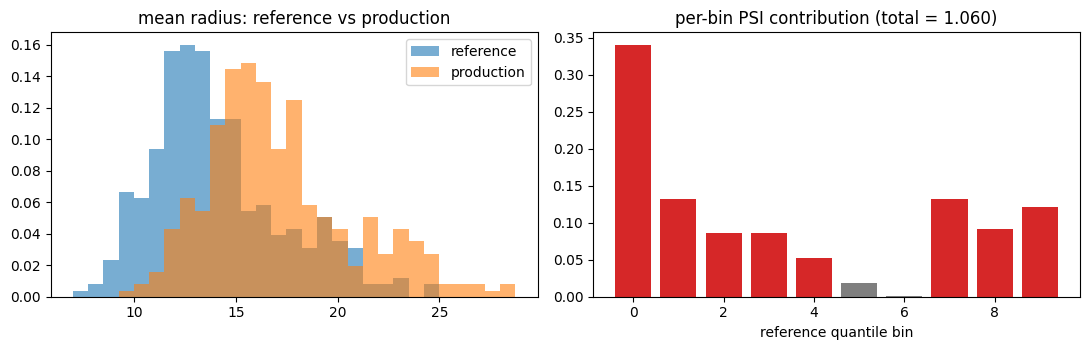

In [9]:
f = "mean radius"
val, contrib, edges = psi(ref[f].values, prod[f].values)
centres = [(-1 if not np.isfinite(edges[i]) else edges[i]) for i in range(len(edges) - 1)]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
bins = np.linspace(min(ref[f].min(), prod[f].min()), max(ref[f].max(), prod[f].max()), 30)
ax[0].hist(ref[f], bins=bins, alpha=0.6, label="reference", density=True)
ax[0].hist(prod[f], bins=bins, alpha=0.6, label="production", density=True)
ax[0].set_title(f"{f}: reference vs production"); ax[0].legend()

ax[1].bar(range(len(contrib)), contrib, color=["tab:red" if c > 0.02 else "tab:gray" for c in contrib])
ax[1].set_title(f"per-bin PSI contribution (total = {val:.3f})")
ax[1].set_xlabel("reference quantile bin")
plt.tight_layout(); plt.show()

## Pitfalls and caveats

Collected while writing this:

- **Binning controls PSI/KL/JS.** Fewer bins hide drift; more bins manufacture
  it from noise. Fix the scheme (10 quantile bins is the credit-scoring
  default), take edges from the **reference only**, and keep it constant over
  time, or your trend is an artefact of the bins.
- **Empty bins break the logs.** Any zero proportion sends KL/PSI to `inf`.
  Floor with `eps`, or merge sparse bins. The `eps` you pick quietly sets the
  ceiling on a per-bin contribution.
- **p-values scale with `n`.** With large production windows the KS / t-test
  p-value is ~0 for drift far too small to matter. Threshold on **effect size**
  (PSI, the KS *statistic*, Wasserstein), not significance, and treat p-values
  as a tie-breaker.
- **Each metric is blind to something.** t-test sees only the mean; KS is weak
  in the tails; Wasserstein isn't scale-free; PSI/JS depend on binning. Report a
  few, not one.
- **Covariate drift is not concept drift.** Inputs can shift with the model
  still correct (as in the AUC above), and inputs can look stable while
  `P(y|x)` rots underneath. These tests are an early-warning layer, not a
  substitute for backtesting against labels once they land.
- **Categorical features** want the same `(p-q)ln(p/q)` PSI machinery but with
  one bin per category and explicit smoothing for unseen categories - no
  quantile edges.

## References

- **PSI** - Bilal Yurdakul, *Statistical Properties of Population Stability
  Index (PSI)* (PhD thesis, WMU, 2018) - derives the thresholds I used:
  <https://scholarworks.wmich.edu/dissertations/3208/>. Practitioner intro:
  <https://www.listendata.com/2015/05/population-stability-index.html>.
- **KS two-sample** - Hodges, *The significance probability of the Smirnov
  two-sample test* (1958); concise summary:
  <https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test>.
- **Wasserstein (1-D / earth mover's)** - Ramdas, Garcia, Cuturi, *On
  Wasserstein Two-Sample Testing* (2017): <https://arxiv.org/abs/1509.02237>.
  Closed form: <https://en.wikipedia.org/wiki/Wasserstein_metric>.
- **KL divergence** - Kullback & Leibler, *On Information and Sufficiency*
  (1951). Cover & Thomas, *Elements of Information Theory*, ch. 2.
- **Jensen-Shannon** - Lin, *Divergence Measures Based on the Shannon Entropy*,
  IEEE Trans. Inf. Theory (1991):
  <https://ieeexplore.ieee.org/document/61115>.
- **Drift taxonomy** - Gama et al., *A Survey on Concept Drift Adaptation*, ACM
  Computing Surveys (2014): <https://dl.acm.org/doi/10.1145/2523813>.
- SciPy reference implementations checked against: `ks_2samp`,
  `wasserstein_distance`, `entropy`, `scipy.spatial.distance.jensenshannon`.